# EDA - Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

df = pd.read_parquet("../data/Reto_data_20251023_122206.parquet")

df.head()

,id,attachments,author,authorCategory,authorCategoryId,authorId,authorURL,automateProjectId,caption,context,contextTitle,country,createdAt,description,engagementRate,facebookAdAccountId,facebookIds,facebookMessengerThreadId,facebookPageId,group,hasImageOrVideo,host,ignored,image,influenceScore,...,metadata,minRating,parentCreatedAt,parentId,parentText,places,preciseId,private,rating,recipients,sentiment,sex,socialType,sourceData,sourceId,sourceLimitations,sourceName,sourceURL,tags,text,threadId,title,type,url,youtubeChannelId
0,c6adb4630994bdee807d387382d526bc,[],Consulta Popular,,,,,,,El camino hacia la consulta popular en Colombia,,co,1750834500000,,,,[],,,portal,False,www.proclamadelpacifico.com,False,,1,...,,,,,,[],es_1750834500000_c6adb4630994bdee807d387382d526bc,False,,[],UNKNOWN,u,,,,[],,https://www.proclamadelpacifico.com/el-camino-...,[],Hasta 1990 el C&oacute;digo Sustantivo del Tra...,c6f5b8840e9675c607bc42a16543c1d72ef4f771759834...,El camino hacia la consulta popular en Colombia,ar,https://www.proclamadelpacifico.com/el-camino-...,
1,9fee3686bd7f2fd45d381a9b388dfb5e,[],Consulta Popular,,,,,,,La Consulta popular constituyente,,co,1750836300000,,,,[],,,portal,False,www.proclamadelpacifico.com,False,,1,...,,,,,,[],es_1750836300000_9fee3686bd7f2fd45d381a9b388dfb5e,False,,[],UNKNOWN,u,,,,[],,https://www.proclamadelpacifico.com/la-consult...,[],La Consulta popular constituyente/El deliberad...,f565efdfc7bd00275467b1e2d8e90036f986e5e50d1896...,La Consulta popular constituyente,ar,https://www.proclamadelpacifico.com/la-consult...,
2,9adb9324d96a398905767afcf428e956,[],Daniel Hernandez,,,,,,,"Empleo juvenil, frente del mercado laboral que...",,co,1750837740000,,,,[],,,portal,False,www.portafolio.co,False,,4,...,,,,,,[],es-co_1750837740000_9adb9324d96a398905767afcf4...,False,,[],UNKNOWN,m,,,,[],,https://www.portafolio.co/economia/empleo/refo...,[],En medio de la expectativa por lo que vendr&aa...,3d97a4b17c73e05726d2a10e10edf6a653cfa03053e7ca...,"Empleo juvenil, frente del mercado laboral que...",ar,https://www.portafolio.co/economia/empleo/refo...,
3,be6ed61346de9fc96e3e797d70d275a9,[],,,,,,,,Petro da marcha atrás con consulta sobre <q>re...,,mx,1750840406000,,,,[],,,portal,False,www.eleconomista.com.mx,False,,4,...,,,,,,[],es-mx_1750840406000_be6ed61346de9fc96e3e797d70...,False,,[],UNKNOWN,u,,,,[],,https://www.eleconomista.com.mx/internacionale...,[],El Senado tampoco autoriz&oacute; a mediados d...,1e19407566ce89c0a86e50c86633f8ccf07ccfdb9e60c2...,Petro da marcha atr&aacute;s con consulta sobr...,ar,https://www.eleconomista.com.mx/internacionale...,
4,4a893f2667aa8eddb4c84fcd09fcd43f,[],,,,,,,,Petro firmó decreto de la <q>reforma</q> <q>la...,,co,1750848960000,,,,[],,,portal,False,www.kienyke.com,False,,3,...,,,,,,[],es_1750848960000_4a893f2667aa8eddb4c84fcd09fcd43f,False,,[],UNKNOWN,u,,,,[],,https://www.kienyke.com/politica/gustavo-petro...,[],Cr&eacute;ditos: X @infopresidencia El preside...,f689aa9604212e6e350dbfb942bc3579f07871b5f8b547...,Petro firm&oacute; decreto de la <q>reforma</q...,ar,https://www.kienyke.com/politica/gustavo-petro...,


In [7]:
df.shape
df.columns 
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 72 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            4795 non-null   object
 1   attachments                   4795 non-null   object
 2   author                        4795 non-null   object
 3   authorCategory                4795 non-null   object
 4   authorCategoryId              4795 non-null   object
 5   authorId                      4795 non-null   object
 6   authorURL                     4795 non-null   object
 7   automateProjectId             4795 non-null   object
 8   caption                       4795 non-null   object
 9   context                       4795 non-null   object
 10  contextTitle                  4795 non-null   object
 11  country                       4795 non-null   object
 12  createdAt                     4795 non-null   object
 13  description       

# Relevant Columns

## Metrics
id, author - authorId, text, liked, engagementRate, title, sourceName, host

## Sentiment
text, language, author, createdAt

## Propagation

threadId, parentId, parentCreatedAt, parentText

In [8]:
cols_interes = [
    "id", "threadId", "parentId", "parentText", "parentCreatedAt",
    "author", "authorId", "authorCategory", "createdAt",
    "text", "title", "language", "country",
    "liked", "engagementRate", "isComment", "isRetweet",
    "sourceName", "url"
]

df_small = df[cols_interes].copy()

df_small.head()


,id,threadId,parentId,parentText,parentCreatedAt,author,authorId,authorCategory,createdAt,text,title,language,country,liked,engagementRate,isComment,isRetweet,sourceName,url
0,c6adb4630994bdee807d387382d526bc,c6f5b8840e9675c607bc42a16543c1d72ef4f771759834...,,,,Consulta Popular,,,1750834500000,Hasta 1990 el C&oacute;digo Sustantivo del Tra...,El camino hacia la consulta popular en Colombia,es,co,[],,False,False,,https://www.proclamadelpacifico.com/el-camino-...
1,9fee3686bd7f2fd45d381a9b388dfb5e,f565efdfc7bd00275467b1e2d8e90036f986e5e50d1896...,,,,Consulta Popular,,,1750836300000,La Consulta popular constituyente/El deliberad...,La Consulta popular constituyente,es,co,[],,False,False,,https://www.proclamadelpacifico.com/la-consult...
2,9adb9324d96a398905767afcf428e956,3d97a4b17c73e05726d2a10e10edf6a653cfa03053e7ca...,,,,Daniel Hernandez,,,1750837740000,En medio de la expectativa por lo que vendr&aa...,"Empleo juvenil, frente del mercado laboral que...",es-co,co,[],,False,False,,https://www.portafolio.co/economia/empleo/refo...
3,be6ed61346de9fc96e3e797d70d275a9,1e19407566ce89c0a86e50c86633f8ccf07ccfdb9e60c2...,,,,,,,1750840406000,El Senado tampoco autoriz&oacute; a mediados d...,Petro da marcha atr&aacute;s con consulta sobr...,es-mx,mx,[],,False,False,,https://www.eleconomista.com.mx/internacionale...
4,4a893f2667aa8eddb4c84fcd09fcd43f,f689aa9604212e6e350dbfb942bc3579f07871b5f8b547...,,,,,,,1750848960000,Cr&eacute;ditos: X @infopresidencia El preside...,Petro firm&oacute; decreto de la <q>reforma</q...,es,co,[],,False,False,,https://www.kienyke.com/politica/gustavo-petro...


## Fix Dates

In [9]:
df_small["createdAt"] = pd.to_datetime(df_small["createdAt"], errors="coerce")
df_small["parentCreatedAt"] = pd.to_datetime(df_small["parentCreatedAt"], errors="coerce")


C:\Users\anfep\AppData\Local\Temp\ipykernel_67692\83462032.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small["createdAt"] = pd.to_datetime(df_small["createdAt"], errors="coerce")
C:\Users\anfep\AppData\Local\Temp\ipykernel_67692\83462032.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small["parentCreatedAt"] = pd.to_datetime(df_small["parentCreatedAt"], errors="coerce")


In [10]:
df_small[["createdAt", "parentCreatedAt"]].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   createdAt        0 non-null      datetime64[ns]
 1   parentCreatedAt  0 non-null      datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 75.0 KB


# Propagation EDA

## How many messages are root against answers?

In [11]:
df_small["is_root"] = df_small["parentId"].replace("", None).isna()

df_small["is_root"].value_counts()

is_root
False    4567
True      228
Name: count, dtype: int64

Only 228 messages are root, this mean that they have empty parentId, they could be first posts, videos and original posts

And 4567 are answers or shared comments

So there are deep active conversations, not only any post

### How many messages has each thread? 

In [12]:
tam_hilos = df_small.groupby("threadId")["id"].count().sort_values(ascending=False)
tam_hilos.head(10)


threadId
tikapi_7520805329748151557                                          2921
tikapi_7520430294948793606                                          1141
7a25d7a5667c9ac29daedcacf4f30da71a02e349edfbfd3f749206cfc42fc8cc     127
14057cc84a11e286ce33f6ebcfb667fbc6e629471ad55e0747e389a50bd28017      70
tikapi_7521161052403322118                                            64
e227ab7efa682ced8d40eb300d00864377c057d71d3aea8b4b0305a34c495498      41
32ad3005be5ed945a6989356b8268a7b98523c6bb444c9194dd9f2b796b7d396      25
tikapi_7521397673275051269                                            23
e83759219e418f3fbf0bc8075dbb74777c4a9f16aaf5c1824b88be9afa9de7cd      21
4603cd6c8bb4dfe771ec5d99a256746c0342f3e802da02c0af6e5b8c1170f60f      14
Name: id, dtype: int64

There are two main threads, each one could be a viral video, so we could say the dataset contains macro-conversations of thousand of conversations

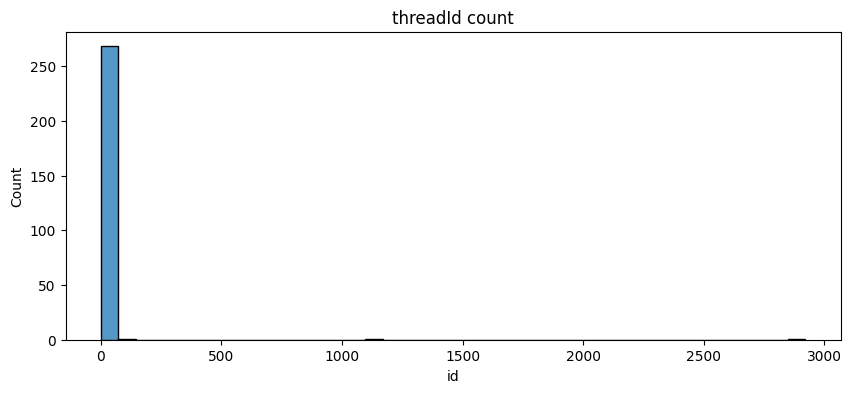

In [17]:
plt.figure(figsize=(10,4))
sns.histplot(tam_hilos, bins=40)
plt.title("threadId count")
plt.show()


## Now we are going to select the top thread to visualize the comment references

In [18]:
hilo_top = tam_hilos.index[0]
hilo_top


'tikapi_7520805329748151557'

In [19]:
df_small[df_small["threadId"] == hilo_top].sort_values("createdAt")[["id","parentId","createdAt","text"]].head(20)


,id,parentId,createdAt,text
930,tikapi_7520805329748151557,,NaT,🚨EL GUERRILLERO PETRO <q>ELIMIN&Oacute;</q> LO...
933,tikapi_7520805329748151557_7520806303167791879,tikapi_7520805329748151557,NaT,😱😱😱😱😱😱😱😱😱
934,tikapi_7520805329748151557_7520806841208587016,tikapi_7520805329748151557,NaT,😂😂😂😂 yo tambi&eacute;n me encanta tu contenido...
935,tikapi_7520805329748151557_7520806857570222869,tikapi_7520805329748151557,NaT,Cositas 😂😂😂😂😂
936,tikapi_7520805329748151557_7520806971516994312,tikapi_7520805329748151557,NaT,🤣🤣🤣 Dios
937,tikapi_7520805329748151557_7520807104653001493,tikapi_7520805329748151557,NaT,jajaja Jajaja hay petristas
939,tikapi_7520805329748151557_7520806420041220872,tikapi_7520805329748151557,NaT,Es genial su contenido 😂😂😂😂😂😂
940,tikapi_7520805329748151557_7520807291303035666,tikapi_7520805329748151557,NaT,😃😃😃😃😃😃😃😂
941,tikapi_7520805329748151557_7520807345313022728,tikapi_7520805329748151557,NaT,🤷&zwj;♂️. Y acaso los petristas trabajan?
942,tikapi_7520805329748151557_7520807424098648839,tikapi_7520805329748151557,NaT,"Que m&aacute;s se puede esperar de un asesino,..."


As we can see, all comments references directly to the root, most of the comments reply to the original video.

# Sentiment EDA

## Texts Lenght

In [20]:
df_small["len_words"] = df_small["text"].str.split().str.len()
df_small["len_words"].describe()

count    4795.000000
mean       43.371011
std       176.761014
min         0.000000
25%         4.000000
50%         9.000000
75%        20.000000
max      3759.000000
Name: len_words, dtype: float64

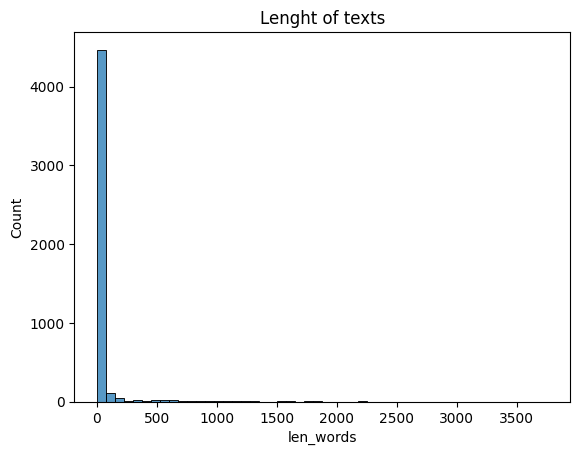

In [21]:
sns.histplot(df_small["len_words"], bins=50)
plt.title("Lenght of texts")
plt.show()


### Languages

In [22]:
df_small["language"].value_counts().head(10)


language
es       4698
es-es      48
es-co      38
es-mx       3
es-pe       2
es-ve       1
es-hn       1
es-gt       1
es-ar       1
es-ec       1
Name: count, dtype: int64

All of them are in Spanish but in different slang, so we are going to work with an Spanish LLM

## Random selected text

In [23]:
df_small["text"].sample(5).values


array(['ustedes los petristas no piensan m&aacute;s all&aacute;.... fuera petro',
       'pue papi no me dan trabajo f&aacute;cil',
       'Demuestre lo contrario😂',
       'trabajas en la casa durmiendo 😂😂😂😂😂😂😂😂', '😳'], dtype=object)

# Metrics EDA

## Messages by Author

In [25]:
users = df_small.groupby("author")["id"].count().sort_values(ascending=False)
users.head(10)


author
                                468
Merryluz777 (@merryluz7771)      20
marcepoboo (@marcepiboo)         17
Martha ⭐ (@marthalestrella6)     17
vlakho (@vlakho731)              17
maso (@maso8014)                 15
tahilis19 (@tahilis19)           14
Stev_G. A. (@stev_g.a)           12
Grok (@grok)                     12
seba (@sebastian658322)          12
Name: id, dtype: int64

Almost 10% of the dataset has empty authors... What are those?

In [28]:
df_small[df_small["author"].str.strip() == ""].sample(5)[["text","title","sourceName","url"]]


,text,title,sourceName,url
41,Jimenez David Desde el 2002 cuando se <q>elimi...,,Presidencia de la República de Colombia,https://www.facebook.com/569052197918981/posts...
10,Imprimir/Enviar Imprimir Correo electr&oacute;...,Petro firma la ley de la <q>reforma</q> <q>lab...,,https://www.elinformador.com.co/index.php/gene...
4324,🫕,,Noticias Caracol,https://www.facebook.com/653046236863156/posts...
2805,Jhon Edison Correa Arbelaez <q>Elimina</q> la ...,,Blu Radio,https://www.facebook.com/659118342924375/posts...
3073,"Marleny Rangel Pico No, es falso que la <q>ref...",,Publimetro Colombia,https://www.facebook.com/628083576013806/posts...


Those are news, and articles, so we are going to make two types of messages:

1. Social Messages with valid author - These participate in metrics
2. News or empty messages with empty author - These do not participate in metrics

In [29]:
df_small["author_clean"] = df_small["author"].str.strip()
df_social = df_small[df_small["author_clean"] != ""]
df_news = df_small[df_small["author_clean"] == ""]


90% of messages have an author, but the 10% belong to content without an author, so they are going to excluded from the influence analysis per user.

This because, propagation depends on
* threadId
* parentId
* createdAt

So, if the message has no author, but has 
* valid threadId
* correct parentId
* timestamp

it can be used in the propagation graph.

Basically, a notice can generate a conversation without a human "author", but it does affect metrics.

### Create column for clasification

In [33]:
df_small["is_real_user"] = df_small["author"].str.strip() != ""


### Top influent users

Now we want to know if sourcename works to identify real authors

In [34]:
df_social = df_small[df_small["is_real_user"]]


In [35]:
df_small.groupby(["is_real_user","sourceName"])["id"].count().head(20)


is_real_user  sourceName                             
False                                                     82
              Alejo Vergel                                 1
              Blu Radio                                  130
              Cali es Cali                                 1
              Cambio                                       2
              Caracol Radio                                4
              Clara Lopez O                                1
              Daniel Quintero Calle                        1
              Diario La República                          1
              El Espectador                                3
              El Tiempo                                    8
              El Universal                                 1
              Forbes Colombia                              1
              Gustavo Petro                                3
              Hoy Diario del Magdalena                     1
              Infobae Colombia 

In [36]:
df_small["is_real_user"] = df_small["author"].str.strip() != ""

df_report = (
    df_small
    .groupby(["is_real_user", "sourceName"])["id"]
    .count()
    .reset_index()
    .sort_values(by=["is_real_user", "id"], ascending=[True, False])
)

df_report.head(20)


,is_real_user,sourceName,id
20,False,Noticias Caracol,192
2,False,Blu Radio,130
0,False,,82
22,False,Presidencia de la República de Colombia,11
10,False,El Tiempo,8
5,False,Caracol Radio,4
27,False,Revista Semana,4
9,False,El Espectador,3
13,False,Gustavo Petro,3
16,False,LU17.com,3


With this information, we have to manage two types of content:

* Real users: Top influencers, etc.
* Entities: Influent posts, narrative analysis, propagation analysis...

In [ ]:
df_social = df_small[df_small["is_real_user"]]
df_posts = df_small